In [1]:
from br3 import *
import br3 as code
import time
import matplotlib.pyplot as plt
import numpy as np
import itertools

In [2]:
params = {
    'amin': 75, 
    'amax': 90, 
    'bmin': 500, 
    'bmax': 600, 
    'p1': 0.1, 
    'p2': 0.01, 
    'p3': 0.3
}

## Task 1

in the pdf

## Task 2

In [3]:
def expected_value(val, prob):
    np.testing.assert_almost_equal(np.sum(prob), 1, decimal=6)
    return np.sum(prob * val)

In [4]:

def variance(val, prob):
    exp = expected_value(val, prob)
    np.testing.assert_almost_equal(np.sum(prob), 1, decimal=6)
    return np.sum(prob * (val - exp) ** 2)

In [5]:
functions = {
    'pa': pa,
    'pb': pb,
    'pc': pc,
    'pd': pd
}

def model_results(model_number):
    print(f"\nModel {model_number}")
    print(f"{'Function':<10} {'Expected Value':<20} {'Variance':<20}")
    print("-" * 50)
    
    for func_name, func in functions.items():
        prob, val = func(params, model_number)
        exp_val = expected_value(val, prob)
        var_val = variance(val, prob)
        print(f"{func_name:<10} {exp_val:<20.2f} {var_val:<20.2f}")

In [6]:
model_results(1)


Model 1
Function   Expected Value       Variance            
--------------------------------------------------
pa         82.50                21.25               
pb         550.00               850.00              
pc         13.75                13.17               
pd         17.87                25.14               


In [7]:
model_results(2)


Model 2
Function   Expected Value       Variance            
--------------------------------------------------
pa         82.50                21.25               
pb         550.00               850.00              
pc         13.75                14.05               
pd         17.87                26.63               


## Task 3

In [8]:
def plots(model):
    a_prob, a_val = pa(params, model)
    b_prob, b_val = pb(params, model)
    d_prob, d_val = pd(params, model)
    
    a = int(round(expected_value(a_val, a_prob)))
    b = int(round(expected_value(b_val, b_prob)))
    d = int(round(expected_value(d_val, d_prob)))

    distributions = [
        {'func': pc, 'args': (params, model), 'title': 'pc'},
        {'func': pc_a, 'args': (np.array([a]), params, model), 'title': 'pc_a'},
        {'func': pc_b, 'args': (np.array([b]), params, model), 'title': 'pc_b'},
        {'func': pc_d, 'args': (np.array([d]), params, model), 'title': 'pc_d'},
        {'func': pc_ab, 'args': (np.array([a]), np.array([b]), params, model), 'title': 'pc_ab'},
        {'func': pc_abd, 'args': (np.array([a]), np.array([b]), np.array([d]), params, model), 'title': 'pc_abd'}
    ]

    probs = []
    vals = []
    for dist in distributions:
        prob, val = dist['func'](*dist['args'])
        if dist['title'] == 'pc_ab':
            prob = prob[:, 0]
        elif dist['title'] == 'pc_abd':
            prob = prob.reshape(691, 1)[:, 0]
        probs.append(np.squeeze(prob))
        vals.append(np.squeeze(val))

    
    fig, axs = plt.subplots(2, 3, figsize=(15, 10))
    for ax, prob, val, dist in zip(axs.flat, probs, vals, distributions):
        exp_val = expected_value(val, prob)
        var_val = variance(val, prob)
            
        ax.plot(val, prob)
        ax.fill_between(val, prob, alpha=0.2)
        ax.grid(True)
        ax.set_xlim(0, 50)
        ax.set_title(f"{dist['title']}")
        print(f"{dist['title']}: E = {exp_val:.2f}, Var = {var_val:.2f}")
        ax.set_xlabel('Value')
        ax.set_ylabel('Probability')
        
    plt.tight_layout()
    plt.show()

pc: E = 13.75, Var = 13.17
pc_a: E = 13.70, Var = 12.91
pc_b: E = 13.75, Var = 13.08
pc_d: E = 13.90, Var = 1.53
pc_ab: E = 13.70, Var = 12.82
pc_abd: E = 13.89, Var = 1.53


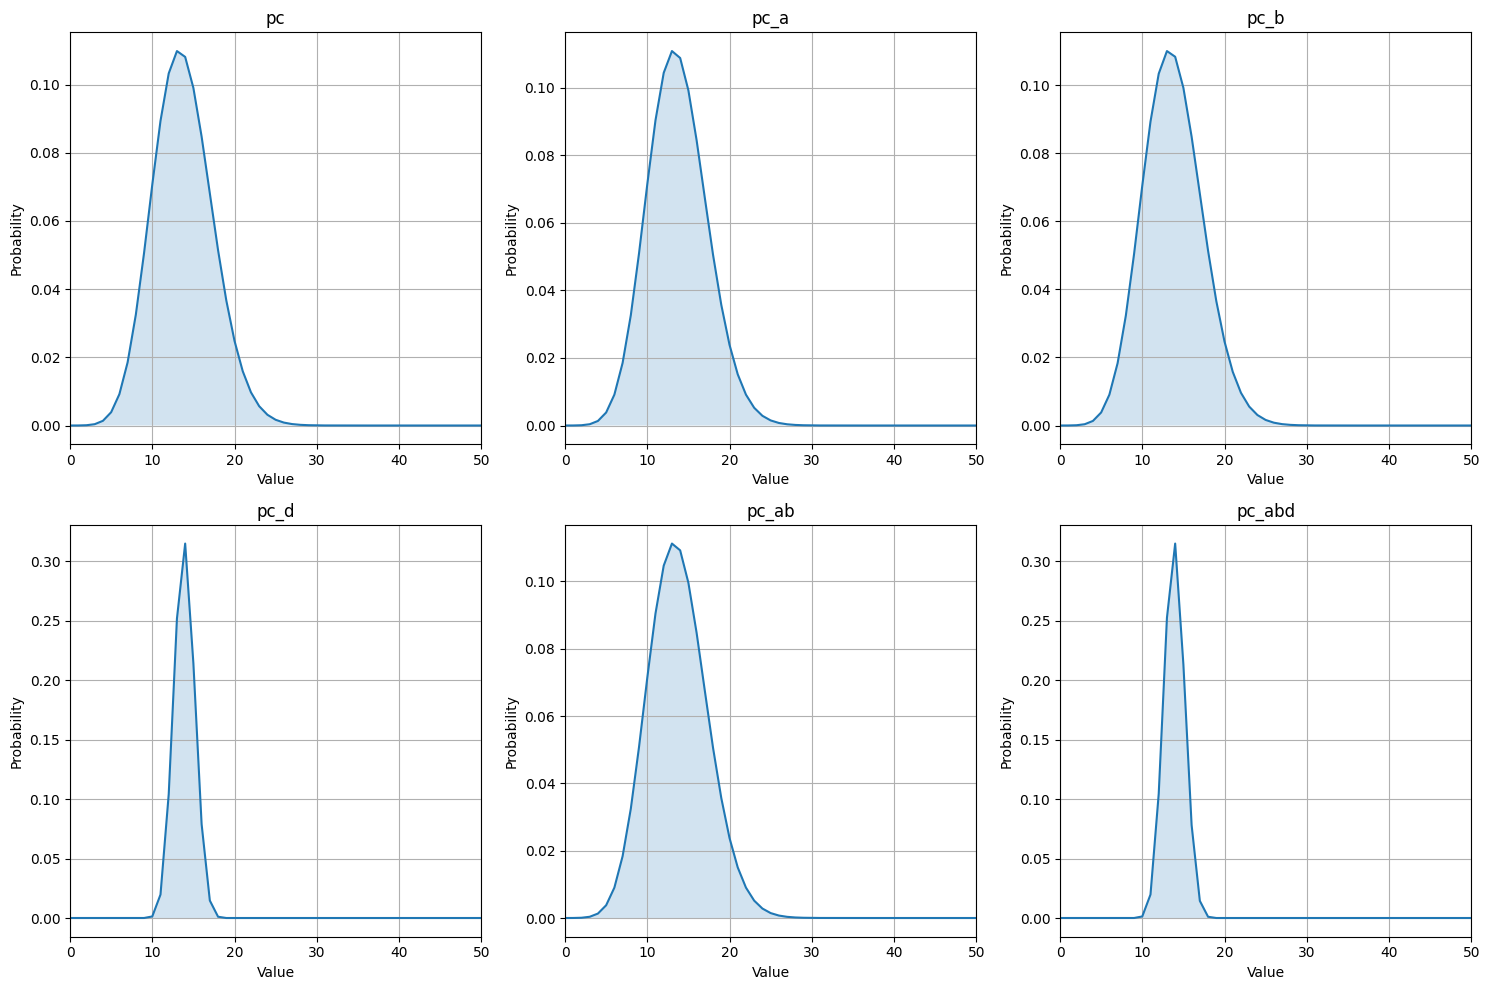

In [9]:
plots(1)

pc: E = 13.75, Var = 14.05
pc_a: E = 13.70, Var = 13.78
pc_b: E = 13.75, Var = 13.96
pc_d: E = 13.89, Var = 1.54
pc_ab: E = 13.70, Var = 13.70
pc_abd: E = 13.89, Var = 1.54


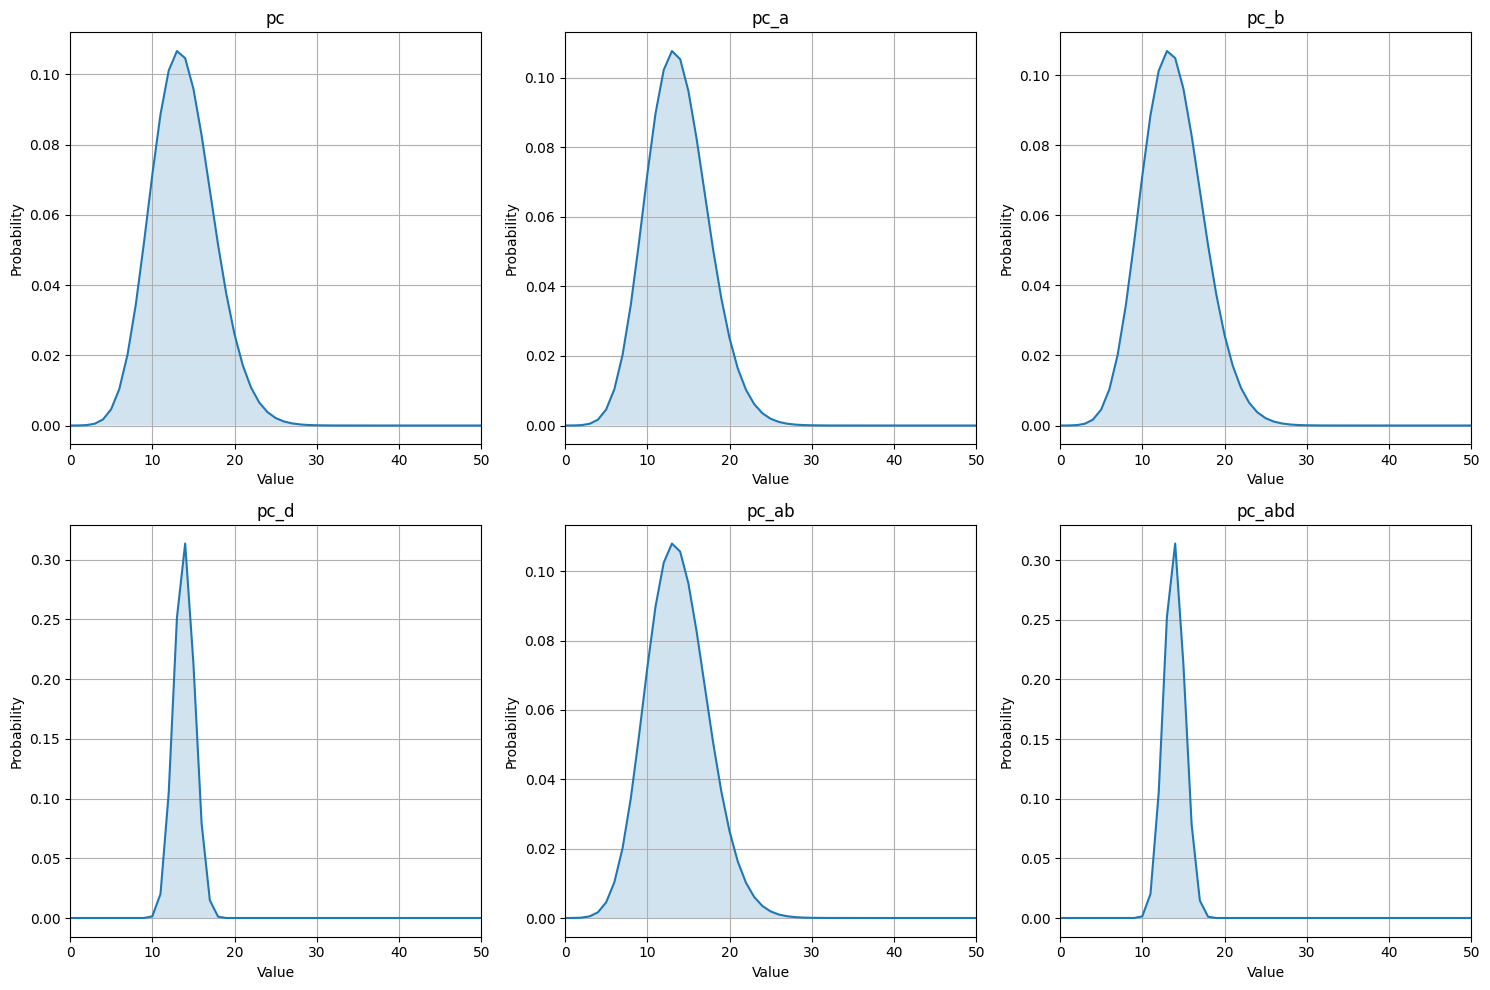

In [10]:
plots(2)

## Task 4

In [11]:
a = np.arange(75, 91)
b = np.arange(500, 601)
d = np.arange(0, 2 * (90 + 600) + 1)

p_c_a, val_c_a = pc_a(a, params, model = 1)
p_c_b, val_c_b = pc_b(b, params, model = 1)
p_c_d, val_c_d = pc_d(d, params, model = 1)

/Users/asahium/Documents/GitHub/university-homeworks/CUB/BMML/hw1/br3.py:102: RuntimeWarning: invalid value encountered in divide
  p = num / num.sum(axis=0)


In [12]:
def calc_var(p_array, val_array, num_columns):
    variances = []
    nan_count = 0
    for i in range(num_columns):
        column = p_array[:, i]
        if np.isnan(column).any():
            variances.append(0)
            nan_count += 1
        else:
            variances.append(variance(val_array, column))
    return variances, np.nanmean(variances), nan_count

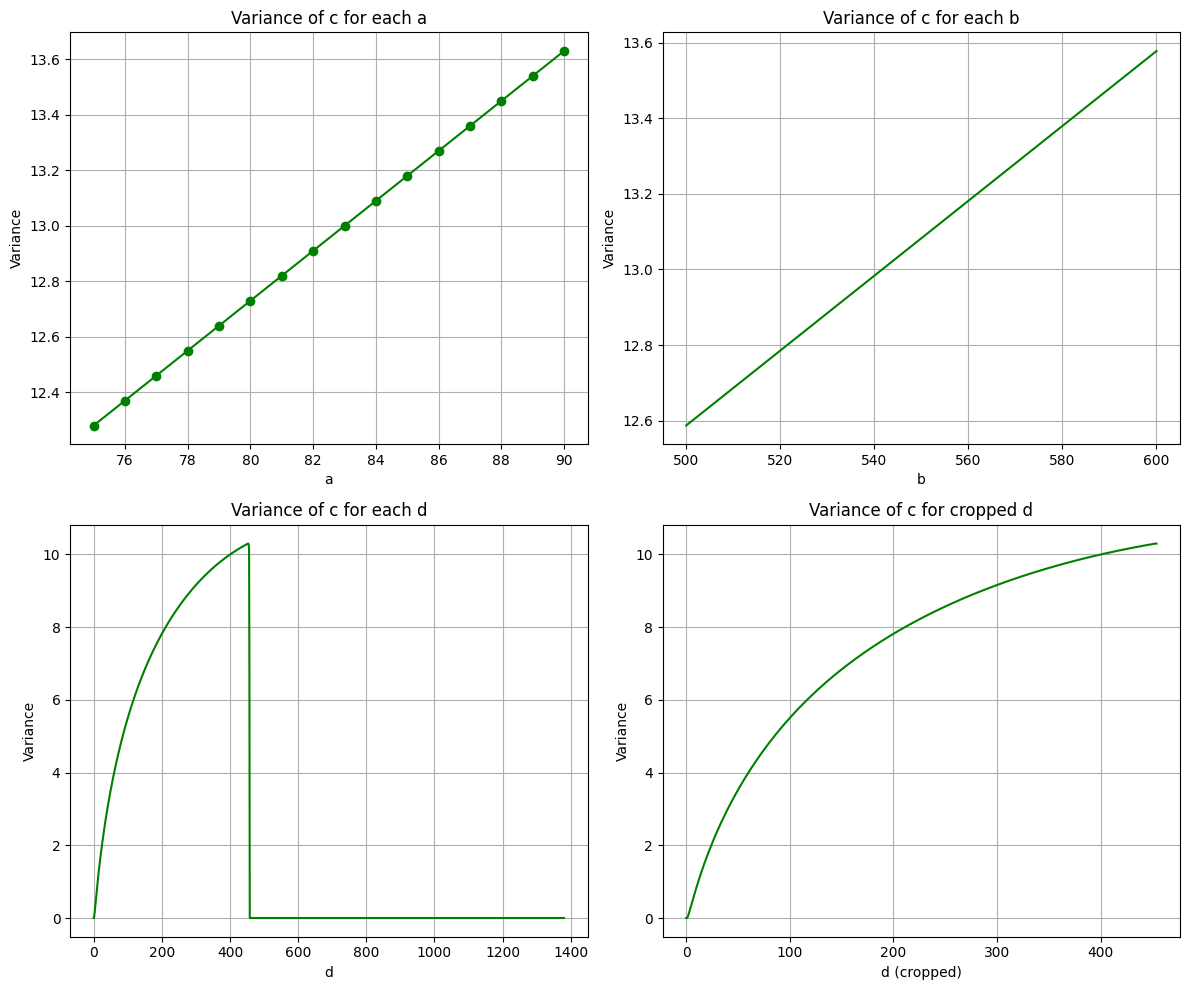

Average variance for p_c_a: 12.95
Average variance for p_c_b: 13.08
Average variance for p_c_d: 2.46


In [13]:
num_columns_c_a = p_c_a.shape[1]
var_c_a, avg_var_c_a, _ = calc_var(p_c_a, val_c_a, num_columns_c_a)

num_columns_c_b = p_c_b.shape[1]
var_c_b, avg_var_c_b, _ = calc_var(p_c_b, val_c_b, num_columns_c_b)

num_columns_c_d = p_c_d.shape[1]
var_c_d, avg_var_c_d, nan_count = calc_var(p_c_d, val_c_d, num_columns_c_d)

var_c_d_cropped = np.array(var_c_d[:455])
d_cropped = np.array(d[:455])

fig, axs = plt.subplots(2, 2, figsize=(12, 10))

axs[0, 0].plot(a, var_c_a, marker='o', linestyle='-', color='g')
axs[0, 0].set_xlabel('a')
axs[0, 0].set_ylabel('Variance')
axs[0, 0].set_title(f'Variance of c for each a')
axs[0, 0].grid(True)

axs[0, 1].plot(b, var_c_b, linestyle='-', color='g')
axs[0, 1].set_xlabel('b')
axs[0, 1].set_ylabel('Variance')
axs[0, 1].set_title(f'Variance of c for each b')
axs[0, 1].grid(True)

axs[1, 0].plot(d, var_c_d, linestyle='-', color='g')
axs[1, 0].set_xlabel('d')
axs[1, 0].set_ylabel('Variance')
axs[1, 0].set_title(f'Variance of c for each d')
axs[1, 0].grid(True)

axs[1, 1].plot(d_cropped, var_c_d_cropped, linestyle='-', color='g')
axs[1, 1].set_xlabel('d (cropped)')
axs[1, 1].set_ylabel('Variance')
axs[1, 1].set_title(f'Variance of c for cropped d')
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

print(f"Average variance for p_c_a: {avg_var_c_a:.2f}")
print(f"Average variance for p_c_b: {avg_var_c_b:.2f}")
print(f"Average variance for p_c_d: {avg_var_c_d:.2f}")

Var[c|d] < Var[c|b] and Var[c|d] < Var[c|a] for any valid values a, b, d


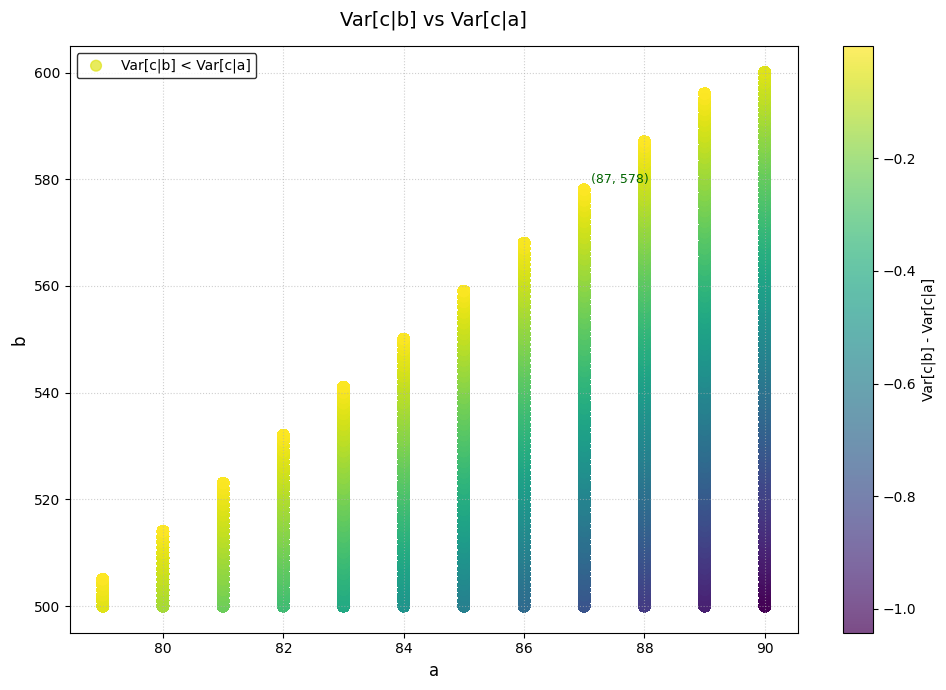

In [14]:
c_b_less_c_a = []
c_b_not_less_c_a = []
c_d_less_c_b_a = []

for i, a_val in enumerate(a):
    for j, b_val in enumerate(b):
        for k, d_val in enumerate(d):
            if var_c_b[j] < var_c_a[i]:
                c_b_less_c_a.append((int(a_val), int(b_val)))
            else:
                c_b_not_less_c_a.append((int(a_val), int(b_val)))
            if var_c_d[k] < var_c_b[j] and var_c_d[k] < var_c_a[i]:
                c_d_less_c_b_a.append((int(a_val), int(b_val), int(d_val)))

all_combinations = set(itertools.product(a, b, d))
c_d_less_c_b_a_set = set(c_d_less_c_b_a)
if all_combinations == c_d_less_c_b_a_set:
    print("Var[c|d] < Var[c|b] and Var[c|d] < Var[c|a] for any valid values a, b, d")
else:
    missing_combinations = all_combinations - c_d_less_c_b_a_set
    print("No")

x1, y1 = zip(*c_b_less_c_a) if c_b_less_c_a else ([], [])
x2, y2 = zip(*c_b_not_less_c_a) if c_b_not_less_c_a else ([], [])

plt.figure(figsize=(10, 7))
sc1 = plt.scatter(x1, y1, c=[var_c_b[b.tolist().index(y)] - var_c_a[a.tolist().index(x)] 
                           for x, y in zip(x1, y1)], cmap='viridis', marker='o', s=60, alpha=0.7, 
                           label=r'Var[c|b] < Var[c|a]')

plt.colorbar(sc1, label='Var[c|b] - Var[c|a]', orientation='vertical')

plt.xlabel('a', fontsize=12)
plt.ylabel('b', fontsize=12)
plt.title('Var[c|b] vs Var[c|a]', fontsize=14, pad=15)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=10, loc='upper left', frameon=True, edgecolor='black')

if c_b_less_c_a:
    max_diff_idx = np.argmax([var_c_b[b.tolist().index(y)] - var_c_a[a.tolist().index(x)] 
                              for x, y in c_b_less_c_a])
    x_max, y_max = c_b_less_c_a[max_diff_idx]
    plt.annotate(f'({x_max}, {y_max})', (x_max, y_max), xytext=(5, 5), textcoords='offset points', 
                 fontsize=9, color='darkgreen')

plt.tight_layout()
plt.show()

## Task 5

In [15]:
def test_distribution(f, model, arg_long, arg_short, size_long, size_short):
    # Check if function exists
    if not hasattr(code, f):
        raise Exception(f'Function {f} for model {model} is not found.')
    # Run with vector inputs
    prob, var = getattr(code, f)(*arg_long, params, model)
    if var.shape != (size_long[0],):
        raise Exception(f'Function {f} for model {model} returns distribution support of the wrong size: {var.shape} instead of {(size_long[0],)}.')
    if prob.shape != size_long:
        raise Exception(f'Function {f} for model {model} returns distribution probabilities of the wrong size: {prob.shape} instead of {size_long}.')
    if np.sum(np.isnan(prob)) != 0 or np.sum(np.isnan(var)) != 0:
        raise Exception(f'Function {f} for model {model} returns NaNs.')
    # Run with scalar inputs and measure time
    t_start = time.perf_counter()
    prob, var = getattr(code, f)(*arg_short, params, model)
    t = time.perf_counter() - t_start
    if prob.shape != size_short:
        raise Exception(f'Function {f} for model {model} returns distribution probabilities of the wrong size: {prob.shape} instead of {size_short}.')
    print(f'{f}, model {model}: \t ok; \t time: {t:.4f} seconds')
    return prob, var

In [16]:
a = np.arange(80, 82)
b = np.arange(500, 503)
d = np.arange(400, 404)

In [17]:
alen = params['amax'] - params['amin'] + 1
blen = params['bmax'] - params['bmin'] + 1
clen = params['amax'] + params['bmax'] + 1
dlen = (params['amax'] + params['bmax']) * 2 + 1

In [18]:
configs = {
    'pa': ([], (alen,)),
    'pb': ([], (blen,)),
    'pc': ([], (clen,)),
    'pd': ([], (dlen,)),
    'pc_a': ([a], (clen, a.size)),
    'pc_b': ([b], (clen, b.size)),
    'pc_d': ([d], (clen, d.size)),
    'pc_ab': ([a, b], (clen, a.size, b.size)),
    'pc_abd': ([a, b, d], (clen, a.size, b.size, d.size)),
    'pb_a': ([a], (blen, a.size)),
    'pb_d': ([d], (blen, d.size)),
    'pb_ad': ([a, d], (blen, a.size, d.size))
}

In [19]:
args_long = {k: v[0] for k, v in configs.items()}
sizes_long = {k: v[1] for k, v in configs.items()}
args_short = {k: [arr[:1] for arr in v[0]] for k, v in configs.items()}
sizes_short = {k: tuple([v[1][0]] + [1] * (len(v[1]) - 1)) for k, v in configs.items()}

ff = ['pc', 'pc_a', 'pc_b', 'pc_d', 'pc_ab', 'pc_abd', 'pd']
for f in ff:
    for dim in [1, 2]:
        test_distribution(f, dim, args_long[f], args_short[f], sizes_long[f], sizes_short[f])

pc, model 1: 	 ok; 	 time: 0.0192 seconds
pc, model 2: 	 ok; 	 time: 0.0539 seconds
pc_a, model 1: 	 ok; 	 time: 0.0075 seconds
pc_a, model 2: 	 ok; 	 time: 0.0051 seconds
pc_b, model 1: 	 ok; 	 time: 0.0007 seconds
pc_b, model 2: 	 ok; 	 time: 0.0006 seconds
pc_d, model 1: 	 ok; 	 time: 0.0441 seconds
pc_d, model 2: 	 ok; 	 time: 0.0721 seconds
pc_ab, model 1: 	 ok; 	 time: 0.0001 seconds
pc_ab, model 2: 	 ok; 	 time: 0.0001 seconds
pc_abd, model 1: 	 ok; 	 time: 0.0241 seconds
pc_abd, model 2: 	 ok; 	 time: 0.0197 seconds
pd, model 1: 	 ok; 	 time: 0.0457 seconds
pd, model 2: 	 ok; 	 time: 0.0788 seconds


## Task 6

in the pdf